# Aula 03: Iterated Local Search (ILS)

Na aula anterior, aprendemos que a Busca Local é excelente para refinar soluções, mas tem um "defeito fatal": ela para assim que encontra o primeiro **Ótimo Local**, sem garantia de que este seja o melhor resultado possível.

Nesta aula, estudaremos o **Iterated Local Search (ILS)**, uma metaheurística simples e poderosa projetada especificamente para "chutar" o algoritmo para fora dessas armadilhas.

## 1. O Conceito Fundamental

O ILS baseia-se na ideia de que é melhor buscar o ótimo global navegando por uma sequência de **ótimos locais**, em vez de recomeçar a busca do zero aleatoriamente (Restart aleatório).

<div align="center">
  <img src="img/ils.png" width="300px" />
  <p><i>O ILS aplica um "chute" (perturbação) para mover a solução para uma nova bacia de atração.</i></p>
</div>

De acordo com Lourenço et al. (2010), o ILS opera em um ciclo de quatro passos:
1. **Gerar uma solução inicial** (usando uma heurística simples ou gulosa).
2. **Aplicar Busca Local** até atingir o Ótimo Local.
3. **Perturbação (Perturbation)**: Modificar a solução atual de forma que ela saia do ótimo local.
4. **Critério de Aceitação**: Decidir se a nova solução otimizada será a base para a próxima iteração.

## 2. A Arte da Perturbação: Nem Fraca, Nem Forte

O maior desafio do ILS é definir a força da perturbação:

- **Muito Fraca**: O algoritmo volta para o **mesmo** ótimo local de onde saiu, desperdiçando tempo.
- **Muito Forte**: O algoritmo se comporta como um *random restart* (recomeço aleatório), perdendo todo o conhecimento acumulado na busca anterior.

No TSP, uma perturbação comum é o **Double-bridge move**, que troca 4 arestas de uma vez, algo que o movimento 2-opt da busca local dificilmente desfaria em um único passo.

## 3. Implementando ILS no Problema do Caixeiro Viajante

Vamos usar a nossa função `local_search_2opt` da aula anterior e adicionar a lógica de iteração e perturbação.

Distância Final (ILS): 401.08


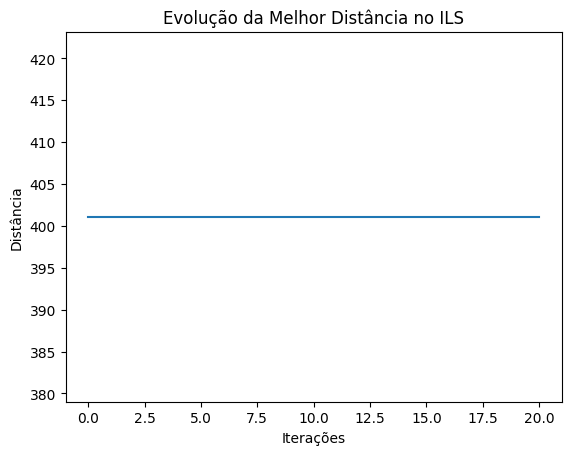

In [6]:
import random
import math
import matplotlib.pyplot as plt

# Funções auxiliares (reaproveitadas das aulas anteriores)
def dist(c1, c2):
    return math.sqrt((c1['x'] - c2['x'])**2 + (c1['y'] - c2['y'])**2)

def calc_total_dist(tour):
    d = sum(dist(tour[i], tour[i+1]) for i in range(len(tour)-1))
    d += dist(tour[-1], tour[0])
    return d

def two_opt_swap(tour, i, k):
    return tour[:i] + tour[i:k+1][::-1] + tour[k+1:]

def local_search_2opt(tour):
    best_tour = tour
    best_dist = calc_total_dist(tour)
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best_tour) - 1):
            for k in range(i + 1, len(best_tour)):
                new_tour = two_opt_swap(best_tour, i, k)
                new_dist = calc_total_dist(new_tour)
                if new_dist < best_dist:
                    best_dist = new_dist
                    best_tour = new_tour
                    improved = True
    return best_tour, best_dist

# --- NOVIDADE: A PERTURBAÇÃO ---
def perturbacao(tour, forca=2):
    """ Realiza trocas aleatórias para tirar a solução do ótimo local """
    new_tour = tour.copy()
    for _ in range(forca):
        i, j = random.sample(range(len(tour)), 2)
        new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

# --- ALGORITMO ILS ---
def iterated_local_search(cidades, max_iter=20):
    # 1. Solução Inicial
    current_tour = cidades.copy()
    random.shuffle(current_tour)
    
    # 2. Primeira Busca Local
    current_tour, current_dist = local_search_2opt(current_tour)
    
    best_tour = current_tour
    best_dist = current_dist
    
    historico = [best_dist]
    
    for i in range(max_iter):
        # 3. Perturbação
        p_tour = perturbacao(current_tour, forca=3)
        
        # 4. Busca Local na solução perturbada
        new_tour, new_dist = local_search_2opt(p_tour)
        
        # 5. Critério de Aceitação (Aqui usamos: só aceita se for melhor global)
        if new_dist < best_dist:
            best_dist = new_dist
            best_tour = new_tour
            current_tour = new_tour
        
        historico.append(best_dist)
        
    return best_tour, best_dist, historico

# Teste do Algoritmo
cidades_teste = [{'id':i, 'x':random.randint(0,100), 'y':random.randint(0,100)} for i in range(20)]
melhor_rota, melhor_dist, log = iterated_local_search(cidades_teste)

print(f"Distância Final (ILS): {melhor_dist:.2f}")
plt.plot(log)
plt.title("Evolução da Melhor Distância no ILS")
plt.xlabel("Iterações")
plt.ylabel("Distância")
plt.show()

## 4. Referências e Leitura Adicional

-
- **Lourenço, H.R.; Martin O.; Stützle T. (2010)**. "Iterated Local Search: Framework and Applications". *Handbook of Metaheuristics*. Kluwer Academic Publishers.